In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Load date and display the data head
from google.colab import drive
# Will ask for authentication, click allow
drive.mount("/content/drive")

# Enter the correct path here
#------YOUR CODE HERE--------

%cd '/content/drive/My Drive'

#------YOUR CODE ENDS--------

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.chdir("/content/drive/MyDrive")


stats = pd.read_csv("nba_model_ready.csv")
stats.head()

ModuleNotFoundError: No module named 'pandas'

In [ ]:
## Split the data into test and training data for the ensemble
from sklearn.model_selection import train_test_split
stats = pd.read_csv("nba_model_ready.csv")
stats.head()

X = stats.drop(columns=["VORP", "OBPM", "DBPM", "BPM", "WS", "WS/48", "Player", "Year", "WAR"])
y = stats["VORP"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

## Set up a parameter grid that can be used in order to determine the best random forest model possible
param_grid = {"n_estimators": [200, 100],
              "max_depth": [None,4,8],
              "min_samples_leaf": [1,2,5],
              "max_features": [1, 3,5]
}

grid = GridSearchCV(RandomForestRegressor(random_state = 42), param_grid, cv=5, n_jobs=-1, scoring = 'r2')
grid.fit(X_train, y_train)


best_rf_model = grid.best_estimator_
y_test_pred = best_rf_model.predict(X_test)
y_train_pred = best_rf_model.predict(X_train)


## Compare our results to VORP in this model to determine the success of the rf model
rf_mse_test = mean_squared_error(y_test, y_test_pred)
rf_mse_train = mean_squared_error(y_train, y_train_pred)

rf_r2_test = r2_score(y_test, y_test_pred)
rf_r2_train = r2_score(y_train, y_train_pred)

print("RF Test MSE:", rf_mse_test)
print("RFTrain MSE:", rf_mse_train)
print("RF Test R2:", rf_r2_test)
print("RF Train R2:", rf_r2_train)

print("Best RF parameters", grid.best_params_)
print("Best RF score", grid.best_score_)

RF Test MSE: 0.1696948462998103
RFTrain MSE: 0.02548209774614476
RF Test R2: 0.9090577720159663
RF Train R2: 0.9866842676146568
Best RF parameters {'max_depth': None, 'max_features': 5, 'min_samples_leaf': 1, 'n_estimators': 100}
Best RF score 0.9000715008199895


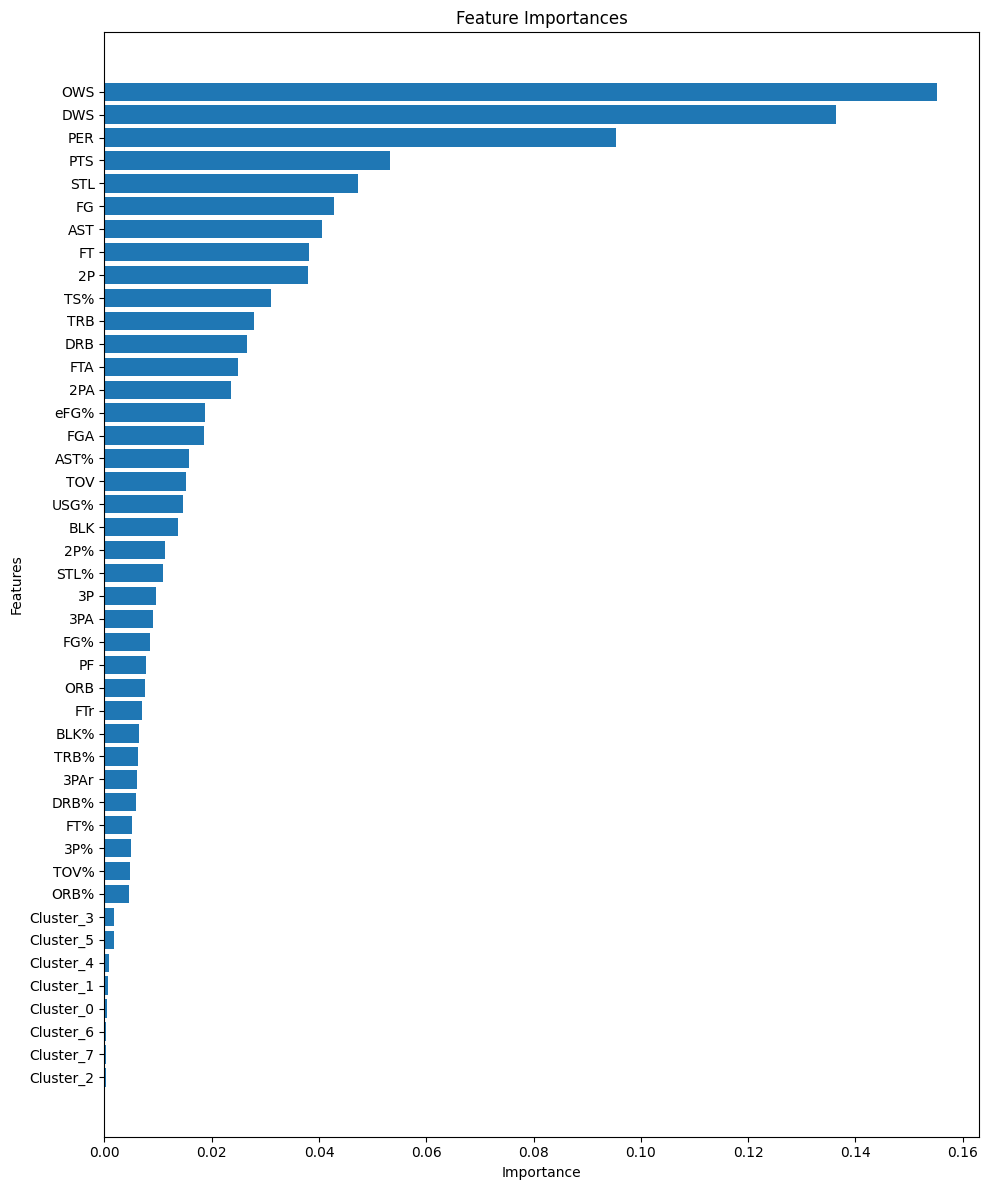

In [ ]:
## Plot the importance of the features that are generated by the model

rf_feature_importances = pd.DataFrame(best_rf_model.feature_importances_,
                                   index = X_train.columns,
                                    columns=['importance']).sort_values('importance', ascending=False)
## Plot the feature importances so we understand what is driving our model
plt.figure(figsize=(10,12))
plt.barh(rf_feature_importances.index, rf_feature_importances["importance"])
plt.gca().invert_yaxis()

plt.title("Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

In [ ]:
## implement the random forest war into the dataset
stats["WAR_rf"] = best_rf_model.predict(X)
stats.head()

,Year,Player,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,...,Cluster_0,Cluster_1,Cluster_2,Cluster_3,Cluster_4,Cluster_5,Cluster_6,Cluster_7,WAR,WAR_rf
0,2006.0,Shareef Abdur-Rahim,17.2,0.588,0.035,0.440,6.4,14.8,10.6,13.2,...,False,False,False,False,False,False,True,False,1.503681,1.383
1,2006.0,Malik Allen,11.5,0.504,0.004,0.154,7.2,15.7,11.5,4.9,...,False,False,False,False,False,False,True,False,-0.478933,-0.305
2,2006.0,Ray Allen,22.2,0.590,0.435,0.239,2.8,10.6,6.6,17.2,...,False,False,False,False,False,False,False,True,3.848973,3.929
3,2006.0,Tony Allen,12.9,0.554,0.124,0.489,4.1,9.6,6.9,11.2,...,False,True,False,False,False,False,False,False,-0.286827,0.246
4,2006.0,Rafer Alston,12.6,0.475,0.423,0.194,1.8,10.4,6.1,30.8,...,False,True,False,False,False,False,False,False,1.214322,1.502


In [ ]:
leaderboard = stats.sort_values(by="WAR_rf", ascending=False)
leaderboard[leaderboard["Year"] == 2017.0].head(20)
#

,Year,Player,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,...,Cluster_0,Cluster_1,Cluster_2,Cluster_3,Cluster_4,Cluster_5,Cluster_6,Cluster_7,WAR,WAR_rf
5240,2017.0,Russell Westbrook,30.6,0.554,0.300,0.433,5.4,28.8,17.1,57.3,...,False,False,False,True,False,False,False,False,6.896538,10.616
4981,2017.0,James Harden,27.3,0.613,0.493,0.575,3.5,20.9,12.2,50.7,...,False,True,False,False,False,False,False,False,7.495351,8.464
5023,2017.0,LeBron James,27.0,0.619,0.254,0.395,4.0,20.7,12.6,41.3,...,False,False,False,True,False,False,False,False,6.413587,7.104
5063,2017.0,Kawhi Leonard,27.5,0.611,0.294,0.407,3.7,15.7,9.8,18.9,...,False,False,False,True,False,False,False,False,6.121527,6.379
4830,2017.0,Giannis Antetokounmpo,26.1,0.599,0.143,0.486,5.9,22.6,14.3,26.6,...,False,False,False,True,False,False,False,False,6.153418,6.242
4910,2017.0,Stephen Curry,24.6,0.624,0.547,0.251,2.7,11.4,7.3,31.1,...,False,True,False,False,False,False,False,False,5.699579,6.237
4932,2017.0,Kevin Durant,27.6,0.651,0.304,0.374,2.2,23.6,13.6,23.1,...,False,False,False,True,False,False,False,False,5.847908,5.501
5148,2017.0,Chris Paul,26.2,0.614,0.385,0.331,2.5,14.9,8.8,46.8,...,False,True,False,False,False,False,False,False,5.115463,5.116
4879,2017.0,Jimmy Butler,25.1,0.586,0.198,0.540,4.9,13.2,9.0,24.8,...,False,False,False,True,False,False,False,False,6.273786,4.984
5218,2017.0,Karl-Anthony Towns,26.0,0.618,0.186,0.289,11.2,27.8,19.4,13.2,...,False,False,False,False,False,True,False,False,4.624133,4.943


In [ ]:
### Return the clusters into the non dummy variable state so we can easily model out the values they provide
cluster_cols = [col for col in stats.columns if "Cluster_" in col]

stats["Cluster_Label"] = (stats[cluster_cols].idxmax(axis=1).str.replace("Cluster_", "").astype(int))

In [ ]:
top_players_by_cluster = (
    stats.sort_values(["Cluster_Label", "WAR_rf"], ascending=[True, False])
         .groupby("Cluster_Label")
         .head(3)
         [["Cluster_Label", "Player", "Year", "WAR_rf"]]
)

print(top_players_by_cluster)

      Cluster_Label             Player    Year  WAR_rf
3079              0      Nick Collison  2013.0   1.619
5142              0      Zaza Pachulia  2017.0   1.491
3883              0     Brandan Wright  2014.0   1.389
1593              1         Chris Paul  2009.0   8.930
4981              1       James Harden  2017.0   8.464
4463              1      Stephen Curry  2016.0   8.123
884               2      Shane Battier  2008.0   3.758
469               2      Shane Battier  2007.0   3.598
32                2      Shane Battier  2006.0   3.594
5240              3  Russell Westbrook  2017.0  10.616
1914              3       LeBron James  2010.0  10.418
1486              3       LeBron James  2009.0  10.391
4500              4  Langston Galloway  2016.0   0.722
1832              4       Derek Fisher  2010.0   0.572
1430              4      Daniel Gibson  2009.0   0.544
55                5        Elton Brand  2006.0   6.057
4002              5      Anthony Davis  2015.0   5.696
547       

In [ ]:
stats_nn = stats.drop(columns=["WAR", "WAR_rf"])
print(stats_nn.columns)

Index(['Year', 'Player', 'PER', 'TS%', '3PAr', 'FTr', 'ORB%', 'DRB%', 'TRB%',
       'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%', 'OWS', 'DWS', 'WS', 'WS/48',
       'OBPM', 'DBPM', 'BPM', 'VORP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%',
       '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB',
       'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'Cluster_0', 'Cluster_1',
       'Cluster_2', 'Cluster_3', 'Cluster_4', 'Cluster_5', 'Cluster_6',
       'Cluster_7', 'Cluster_Label'],
      dtype='object')


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
import requests
import io
import zipfile

### Prepare the data to run the neural network model on. Set the target to vorp yet again. We don't care about player name in training
stats_nn = stats.drop(columns=["WAR", "WAR_rf"])
X = stats_nn.drop(columns=["VORP", "Player", "Cluster_Label", "Cluster_0","Cluster_1","Cluster_2","Cluster_3","Cluster_4","Cluster_5","Cluster_6","Cluster_7", "BPM", "OBPM", "DBPM", "WS", "WS/48"])
y = stats_nn["VORP"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X)

        Year   PER    TS%   3PAr    FTr  ORB%  DRB%  TRB%  AST%  STL%  ...  \
0     2006.0  17.2  0.588  0.035  0.440   6.4  14.8  10.6  13.2   1.3  ...   
1     2006.0  11.5  0.504  0.004  0.154   7.2  15.7  11.5   4.9   1.0  ...   
2     2006.0  22.2  0.590  0.435  0.239   2.8  10.6   6.6  17.2   1.8  ...   
3     2006.0  12.9  0.554  0.124  0.489   4.1   9.6   6.9  11.2   2.7  ...   
4     2006.0  12.6  0.475  0.423  0.194   1.8  10.4   6.1  30.8   2.3  ...   
...      ...   ...    ...    ...    ...   ...   ...   ...   ...   ...  ...   
5264  2017.0  16.7  0.604  0.002  0.442   8.6  17.3  12.9   9.1   1.8  ...   
5265  2017.0  13.0  0.508  0.006  0.247   9.2  17.0  13.2  12.2   0.7  ...   
5266  2017.0   7.3  0.346  0.000  0.161  10.8  24.9  17.6   5.3   0.9  ...   
5267  2017.0   6.9  0.503  0.448  0.181   1.9  14.2   8.0   6.1   0.9  ...   
5268  2017.0  17.0  0.547  0.013  0.206   7.1  21.9  14.3   8.1   1.1  ...   

        FT%       ORB       DRB       TRB       AST       STL  

In [ ]:
## We want to set a seed here in order to make the results of this model reproduceable.
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf
tf.keras.utils.set_random_seed(42)
np.random.seed(42)

nn_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

nn_model.compile(optimizer='adam', loss='mse')
nn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,545 (17.75 KB)

 Trainable params: 4,545 (17.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = nn_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


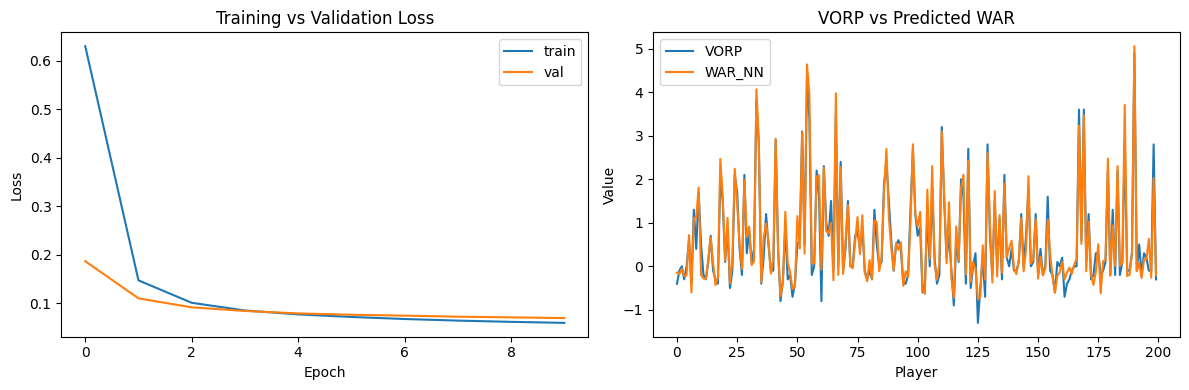

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
# predictions
y_pred = nn_model.predict(X_test).flatten()

#Create the plots to show the performance of the model
plt.figure(figsize=(12, 4))

# Training vs Validation Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# True vs Predicted values
plt.subplot(1, 2, 2)
plt.plot(np.array(y_test)[:200], label='VORP')
plt.plot(y_pred[:200], label='WAR_NN')
plt.legend()
plt.title("VORP vs Predicted WAR")
plt.xlabel("Player")
plt.ylabel("Value")

plt.tight_layout()
plt.show()

In [ ]:
### Create this chunk so we can evaluate the nn model so we can gauge what is successful
y_pred_nn_test = nn_model.predict(X_test).flatten()
y_pred_nn_train = nn_model.predict(X_train).flatten()

nn_mse_test = mean_squared_error(y_test, y_pred_nn_test)
nn_mse_train = mean_squared_error(y_train, y_pred_nn_train)

nn_r2_test = r2_score(y_test, y_pred_nn_test)
nn_r2_train = r2_score(y_train, y_pred_nn_train)

print("NN Test MSE:", nn_mse_test)
print("NN Train MSE:", nn_mse_train)
print("NN Test R2:", nn_r2_test)
print("NN Train R2:", nn_r2_train)


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
NN Test MSE: 0.0759092871153023
NN Train MSE: 0.05888157435886006
NN Test R2: 0.9593189784753469
NN Train R2: 0.9692312895743094


In [ ]:
X = stats_nn.drop(columns=["VORP", "Player", "Cluster_Label", "Cluster_0","Cluster_1","Cluster_2","Cluster_3","Cluster_4","Cluster_5","Cluster_6","Cluster_7", "BPM", "DBPM", "OBPM", "WS", "WS/48"])
X = scaler.transform(X)
stats_nn["WAR_nn"] = nn_model.predict(X)
stats_nn.head()


165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Year,Player,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,...,Cluster_0,Cluster_1,Cluster_2,Cluster_3,Cluster_4,Cluster_5,Cluster_6,Cluster_7,Cluster_Label,WAR_nn
0,2006.0,Shareef Abdur-Rahim,17.2,0.588,0.035,0.440,6.4,14.8,10.6,13.2,...,False,False,False,False,False,False,True,False,6,1.916940
1,2006.0,Malik Allen,11.5,0.504,0.004,0.154,7.2,15.7,11.5,4.9,...,False,False,False,False,False,False,True,False,6,-0.344810
2,2006.0,Ray Allen,22.2,0.590,0.435,0.239,2.8,10.6,6.6,17.2,...,False,False,False,False,False,False,False,True,7,4.092124
3,2006.0,Tony Allen,12.9,0.554,0.124,0.489,4.1,9.6,6.9,11.2,...,False,True,False,False,False,False,False,False,1,-0.039971
4,2006.0,Rafer Alston,12.6,0.475,0.423,0.194,1.8,10.4,6.1,30.8,...,False,True,False,False,False,False,False,False,1,1.523127


In [ ]:
## Connect the war_nn into the stats data so we have all of our final wars and clusters.

War_NN = stats_nn[["Player", "Year", "WAR_nn"]].copy()

stats = stats.merge(
    War_NN,
    on=["Player", "Year"],
    how="left")


In [ ]:
## We now want to add our multiplier for clusters that are good and bad (Those in good clusters will seperate from the bad and the bad will fall)
multiplier_map = {
    0: 1.03, 1: 1.15, 2: 1.075, 3: 1.25, 4: 1,
    5: 1.15, 6: 1.03, 7: 1.075}

# apply to our data and our WAR
stats["WAR_nn"] = stats["WAR_nn"] * stats["Cluster_Label"].map(multiplier_map)
stats["WAR"] = stats["WAR"] * stats["Cluster_Label"].map(multiplier_map)
stats["WAR_rf"] = stats["WAR_rf"] * stats["Cluster_Label"].map(multiplier_map)

It is at this point that our stats data set has all of the players with the WARs calculated using all of our different models. We now want to make this interpretable by naming the clusters, so we can easily value them.

In [ ]:
# Name the columns what the clusters represent so it is easily comprehendable

stats = stats.rename(columns={"Cluster_0": "Rim Protector", "Cluster_1": "Playmaker",
                              "Cluster_2": "3nD Wing", "Cluster_3": "Offensive Enginge",
                              "Cluster_4": "Inefficient Scorer", "Cluster_5": "Paint Beast",
                              "Cluster_6": "Physical Forward", "Cluster_7": "Sharpshooters"})
stats.head()

# Keep the map of the cluster labels becasue this will be needed for simplicity as well
cluster_map = {0: "Rim Protector", 1: "Playmaker", 2: "3nD Wing", 3: "Offensive Engine", 4: "Inefficient Scorer",
                 5: "Paint Beast", 6: "Physical Forward", 7: "Sharpshooter"}

                        VORP    WAR_nn    WAR_rf       WAR
Cluster_Label                                             
Rim Protector       0.043064  0.109290  0.060642  0.024744
Playmaker           1.128609  1.328762  1.280274  1.274758
3nD Wing            0.393644  0.421102  0.405983  0.408368
Offensive Engine    2.321023  3.043874  2.876510  2.910155
Inefficient Scorer -0.248968 -0.256977 -0.248457 -0.264424
Paint Beast         1.591279  1.959767  1.846793  1.826457
Physical Forward    0.149941  0.202051  0.184357  0.134963
Sharpshooter        0.485294  0.511316  0.526607  0.505313


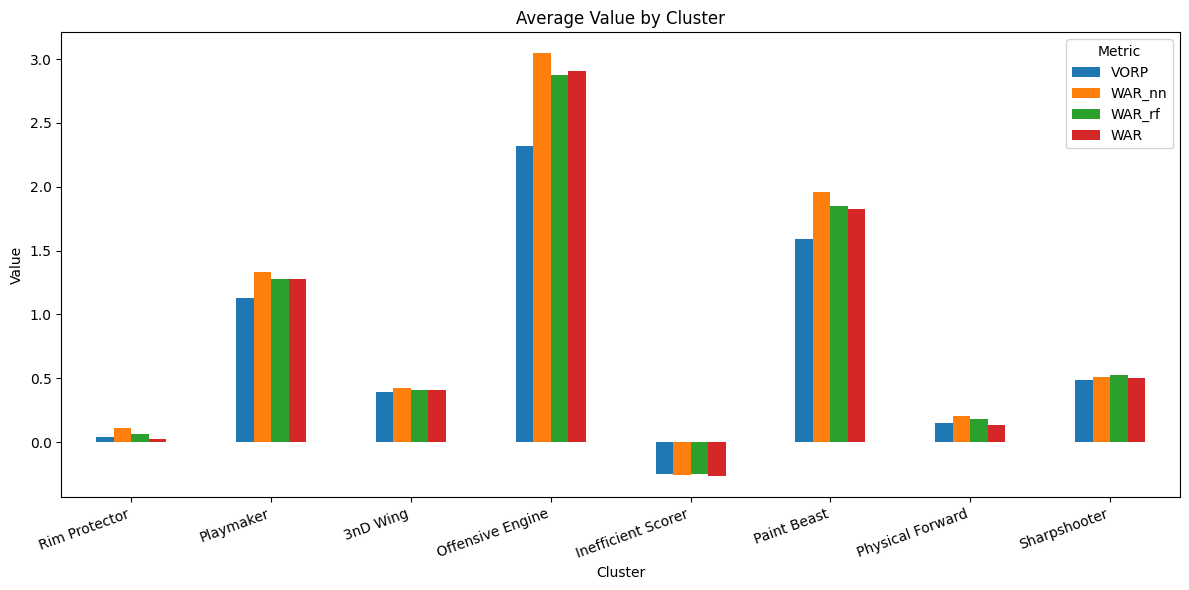

In [ ]:
cluster_summary = stats.groupby("Cluster_Label")[["VORP", "WAR_nn", "WAR_rf", "WAR"]].mean()
cluster_summary.index = cluster_summary.index.map(cluster_map)

print(cluster_summary)

cluster_summary.plot(kind="bar", figsize=(12, 6))
plt.title("Average Value by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Value")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [ ]:
nn_leaderboard = stats.sort_values(by="WAR_nn", ascending=False)
nn_leaderboard[nn_leaderboard["Year"] == 2017.0].head(20)

,Year,Player,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,...,3nD Wing,Offensive Enginge,Inefficient Scorer,Paint Beast,Physical Forward,Sharpshooters,WAR,WAR_rf,Cluster_Label,WAR_nn
5904,2017.0,Russell Westbrook,30.6,0.554,0.300,0.433,5.4,28.8,17.1,57.3,...,False,True,False,False,False,False,8.620673,13.27000,3,13.053526
5617,2017.0,James Harden,27.3,0.613,0.493,0.575,3.5,20.9,12.2,50.7,...,False,False,False,False,False,False,8.619653,9.73360,1,10.639213
5667,2017.0,LeBron James,27.0,0.619,0.254,0.395,4.0,20.7,12.6,41.3,...,False,True,False,False,False,False,8.016983,8.88000,3,10.007542
5448,2017.0,Giannis Antetokounmpo,26.1,0.599,0.143,0.486,5.9,22.6,14.3,26.6,...,False,True,False,False,False,False,7.691772,7.80250,3,8.566542
5503,2017.0,Jimmy Butler,25.1,0.586,0.198,0.540,4.9,13.2,9.0,24.8,...,False,True,False,False,False,False,7.842232,6.23000,3,8.356978
5562,2017.0,Kevin Durant,27.6,0.651,0.304,0.374,2.2,23.6,13.6,23.1,...,False,True,False,False,False,False,7.309885,6.87625,3,7.893485
5713,2017.0,Kawhi Leonard,27.5,0.611,0.294,0.407,3.7,15.7,9.8,18.9,...,False,True,False,False,False,False,7.651908,7.97375,3,7.793022
5538,2017.0,Stephen Curry,24.6,0.624,0.547,0.251,2.7,11.4,7.3,31.1,...,False,False,False,False,False,False,6.554515,7.17255,1,7.518054
5601,2017.0,Rudy Gobert,23.3,0.682,0.002,0.763,13.6,29.5,21.8,5.7,...,False,False,False,True,False,False,6.383652,5.29115,5,6.232579
5681,2017.0,Nikola Jokic,26.4,0.640,0.163,0.267,11.6,27.2,19.5,28.8,...,False,False,False,True,False,False,4.652443,5.42800,5,6.202985


In [ ]:
linear_test_r2 = 0.9120635090421991
linear_test_mse = 0.16408625176687464

## Create a table view so we can see how the three regression models that we made perform
testing_metrics = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Neural Network"],
    "Test R2": [linear_test_r2, rf_r2_test, nn_r2_test],
    "Test MSE": [linear_test_mse, rf_mse_test, nn_mse_test]})

testing_metrics = testing_metrics.round(3)

print(testing_metrics)

               Model  Test R2  Test MSE
0  Linear Regression    0.912     0.164
1      Random Forest    0.909     0.170
2     Neural Network    0.959     0.076


In [ ]:
leaderboard = (
    stats.sort_values(by="WAR_nn", ascending=False)
    .copy()
)

leaderboard["Cluster"] = leaderboard["Cluster_Label"].map(cluster_map)

leaderboard_top10 = leaderboard[[
    "Player", "Year", "VORP", "WAR", "WAR_rf", "WAR_nn", "Cluster"
]].head(10)

print(leaderboard_top10.to_string(index=False))

           Player   Year  VORP       WAR   WAR_rf    WAR_nn          Cluster
     LeBron James 2009.0  11.6 11.609451 12.98875 14.100763 Offensive Engine
     LeBron James 2010.0  10.9 11.213085 13.02250 13.687159 Offensive Engine
Russell Westbrook 2017.0  12.4  8.620673 13.27000 13.053526 Offensive Engine
     LeBron James 2013.0   9.8 11.379732 11.27375 13.008096 Offensive Engine
     LeBron James 2008.0  10.1  9.053261 12.09375 12.349517 Offensive Engine
     Kevin Durant 2014.0   8.5 10.383380  9.01250 11.338130 Offensive Engine
     LeBron James 2006.0   9.5  8.808514 11.30625 11.143738 Offensive Engine
      Dwyane Wade 2009.0   9.7  9.295462 11.85875 11.004243 Offensive Engine
     LeBron James 2011.0   8.2  8.790794 10.15375 10.933329 Offensive Engine
       Chris Paul 2009.0  10.0  9.760376 10.26950 10.859496        Playmaker


In [ ]:
leaderboard = (
    stats[stats["Year"] == 2017].sort_values(by="WAR_nn", ascending=False)
    .copy()
)

leaderboard["Cluster"] = leaderboard["Cluster_Label"].map(cluster_map)

leaderboard_top10 = leaderboard[[
    "Player", "Year", "VORP", "WAR", "WAR_rf", "WAR_nn", "Cluster"
]].head(10)

print(leaderboard_top10.to_string(index=False))

               Player   Year  VORP      WAR   WAR_rf    WAR_nn          Cluster
    Russell Westbrook 2017.0  12.4 8.620673 13.27000 13.053526 Offensive Engine
         James Harden 2017.0   9.0 8.619653  9.73360 10.639213        Playmaker
         LeBron James 2017.0   7.3 8.016983  8.88000 10.007542 Offensive Engine
Giannis Antetokounmpo 2017.0   6.9 7.691772  7.80250  8.566542 Offensive Engine
         Jimmy Butler 2017.0   6.3 7.842232  6.23000  8.356978 Offensive Engine
         Kevin Durant 2017.0   5.2 7.309885  6.87625  7.893485 Offensive Engine
        Kawhi Leonard 2017.0   6.2 7.651908  7.97375  7.793022 Offensive Engine
        Stephen Curry 2017.0   6.2 6.554515  7.17255  7.518054        Playmaker
          Rudy Gobert 2017.0   5.4 6.383652  5.29115  6.232579      Paint Beast
         Nikola Jokic 2017.0   5.3 4.652443  5.42800  6.202985      Paint Beast
